In [1]:
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model

tf.random.set_seed(42)
np.random.seed(42)

IMAGE_SIZE = 256
NUM_CLASSES = 3
BATCH_SIZE = 8
EPOCHS = 20

2026-03-02 13:34:02.938860: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772458443.131613      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772458443.183807      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772458443.615990      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772458443.616032      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772458443.616034      24 computation_placer.cc:177] computation placer alr

In [2]:
train_raw, test_raw = tfds.load(
    "oxford_iiit_pet",
    split=["train", "test"],
    as_supervised=False
)

print(train_raw)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

I0000 00:00:1772458525.367740      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.T9EG41_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.T9EG41_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
<_PrefetchDataset element_spec={'file_name': TensorSpec(shape=(), dtype=tf.string, name=None), 'head_bbox': TensorSpec(shape=(4,), dtype=tf.float32, name=None), 'image': TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None), 'segmentation_mask': TensorSpec(shape=(None, None, 1), dtype=tf.uint8, name=None), 'species': TensorSpec(shape=(), dtype=tf.int64, name=None)}>


Image shape: (500, 500, 3)
Mask shape: (500, 500, 1)
Unique mask values: [1 2 3]


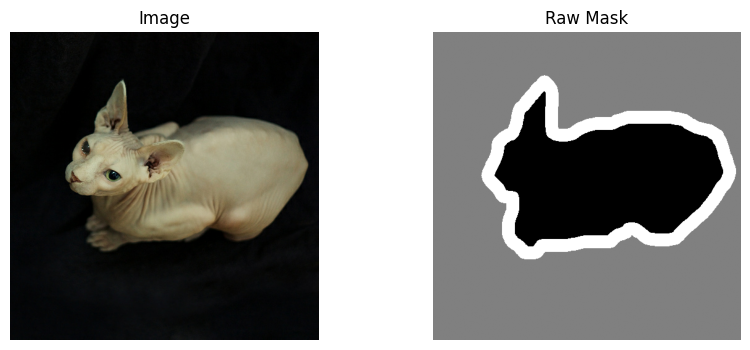

In [3]:
sample = next(iter(train_raw))
img = sample["image"].numpy()
mask = sample["segmentation_mask"].numpy()

print("Image shape:", img.shape)
print("Mask shape:", mask.shape)
print("Unique mask values:", np.unique(mask))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(img); plt.title("Image"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(mask.squeeze(), cmap="gray"); plt.title("Raw Mask"); plt.axis("off")
plt.show()

In [4]:
def preprocess(example):
    image = tf.cast(example["image"], tf.float32) / 255.0
    mask  = tf.cast(example["segmentation_mask"], tf.int32)

    image = tf.image.resize(image, (IMAGE_SIZE, IMAGE_SIZE), method="bilinear")
    mask  = tf.image.resize(mask,  (IMAGE_SIZE, IMAGE_SIZE), method="nearest")

    mask = tf.squeeze(mask, axis=-1)
    mask = mask - 1
    mask = tf.clip_by_value(mask, 0, NUM_CLASSES - 1)
    return image, mask

In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_count = tf.data.experimental.cardinality(train_raw).numpy()
val_size = int(train_count * 0.2)

val_raw = train_raw.take(val_size)
train_raw2 = train_raw.skip(val_size)

train_ds = (train_raw2
            .map(preprocess, num_parallel_calls=AUTOTUNE)
            .shuffle(1024)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

val_ds = (val_raw
          .map(preprocess, num_parallel_calls=AUTOTUNE)
          .batch(BATCH_SIZE)
          .prefetch(AUTOTUNE))

test_ds = (test_raw
           .map(preprocess, num_parallel_calls=AUTOTUNE)
           .batch(BATCH_SIZE)
           .prefetch(AUTOTUNE))

batch = next(iter(train_ds))
print(batch[0].shape, batch[1].shape)

(8, 256, 256, 3) (8, 256, 256)


In [ ]:
def create_unet(input_shape=(512, 512, 3), num_classes=3):
    inputs = layers.Input(shape=input_shape)

    conv1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    conv1 = layers.Conv2D(64, 3, activation='relu', padding='same')(conv1)
    pool1 = layers.MaxPooling2D(2)(conv1)

    conv2 = layers.Conv2D(128, 3, activation='relu', padding='same')(pool1)
    conv2 = layers.Conv2D(128, 3, activation='relu', padding='same')(conv2)
    pool2 = layers.MaxPooling2D(2)(conv2)

    conv3 = layers.Conv2D(256, 3, activation='relu', padding='same')(pool2)
    conv3 = layers.Conv2D(256, 3, activation='relu', padding='same')(conv3)
    pool3 = layers.MaxPooling2D(2)(conv3)

    conv4 = layers.Conv2D(512, 3, activation='relu', padding='same')(pool3)
    conv4 = layers.Conv2D(512, 3, activation='relu', padding='same')(conv4)
    pool4 = layers.MaxPooling2D(2)(conv4)

    conv5 = layers.Conv2D(1024, 3, activation='relu', padding='same')(pool4)
    conv5 = layers.Conv2D(1024, 3, activation='relu', padding='same')(conv5)

    up4 = layers.UpSampling2D(2)(conv5)
    up4 = layers.Conv2D(512, 2, activation='relu', padding='same')(up4)
    merge4 = layers.Concatenate()([conv4, up4])
    conv6 = layers.Conv2D(512, 3, activation='relu', padding='same')(merge4)
    conv6 = layers.Conv2D(512, 3, activation='relu', padding='same')(conv6)

    up3 = layers.UpSampling2D(2)(conv6)
    up3 = layers.Conv2D(256, 2, activation='relu', padding='same')(up3)
    merge3 = layers.Concatenate()([conv3, up3])
    conv7 = layers.Conv2D(256, 3, activation='relu', padding='same')(merge3)
    conv7 = layers.Conv2D(256, 3, activation='relu', padding='same')(conv7)

    up2 = layers.UpSampling2D(2)(conv7)
    up2 = layers.Conv2D(128, 2, activation='relu', padding='same')(up2)
    merge2 = layers.Concatenate()([conv2, up2])
    conv8 = layers.Conv2D(128, 3, activation='relu', padding='same')(merge2)
    conv8 = layers.Conv2D(128, 3, activation='relu', padding='same')(conv8)

    up1 = layers.UpSampling2D(2)(conv8)
    up1 = layers.Conv2D(64, 2, activation='relu', padding='same')(up1)
    merge1 = layers.Concatenate()([conv1, up1])
    conv9 = layers.Conv2D(64, 3, activation='relu', padding='same')(merge1)
    conv9 = layers.Conv2D(64, 3, activation='relu', padding='same')(conv9)

    outputs = layers.Conv2D(num_classes, 1, activation='softmax')(conv9)
    return Model(inputs, outputs, name="U-Net")

model = create_unet((IMAGE_SIZE, IMAGE_SIZE, 3), NUM_CLASSES)
model.summary()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │  9,438,208 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 32, 32,    │          0 │ conv2d_9[0][0]    │
│ (UpSampling2D)      │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 32, 32,    │  2,097,664 │ up_sampling2d[0]

 Total params: 31,031,875 (118.38 MB)

 Trainable params: 31,031,875 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
class MeanIoUArgmax(tf.keras.metrics.MeanIoU):
    def __init__(self, num_classes, name="miou", dtype=None):
        super().__init__(num_classes=num_classes, name=name, dtype=dtype)

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.argmax(y_pred, axis=-1)
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.cast(y_pred, tf.int32)
        return super().update_state(y_true, y_pred, sample_weight)

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="acc"),
             MeanIoUArgmax(NUM_CLASSES)]
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("unet_pets_best.keras", monitor="val_miou", mode="max", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor="val_miou", mode="max", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_miou", mode="max", factor=0.5, patience=2, min_lr=1e-6)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/20


I0000 00:00:1772458549.886119      85 service.cc:152] XLA service 0x7eca5c0e0950 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772458549.886172      85 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772458551.118390      85 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1772458575.147350      85 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


368/368 ━━━━━━━━━━━━━━━━━━━━ 143s 297ms/step - acc: 0.6152 - loss: 0.8807 - miou: 0.2665 - val_acc: 0.6981 - val_loss: 0.7357 - val_miou: 0.3538 - learning_rate: 1.0000e-04
Epoch 2/20
368/368 ━━━━━━━━━━━━━━━━━━━━ 102s 271ms/step - acc: 0.7356 - loss: 0.6607 - miou: 0.4324 - val_acc: 0.7964 - val_loss: 0.5250 - val_miou: 0.5595 - learning_rate: 1.0000e-04
Epoch 3/20
368/368 ━━━━━━━━━━━━━━━━━━━━ 102s 271ms/step - acc: 0.7945 - loss: 0.5184 - miou: 0.5447 - val_acc: 0.8222 - val_loss: 0.4567 - val_miou: 0.5966 - learning_rate: 1.0000e-04
Epoch 4/20
368/368 ━━━━━━━━━━━━━━━━━━━━ 102s 271ms/step - acc: 0.8212 - loss: 0.4614 - miou: 0.5918 - val_acc: 0.8311 - val_loss: 0.4398 - val_miou: 0.6021 - learning_rate: 1.0000e-04
Epoch 5/20
368/368 ━━━━━━━━━━━━━━━━━━━━ 102s 271ms/step - acc: 0.8361 - loss: 0.4248 - miou: 0.6130 - val_acc: 0.8456 - val_loss: 0.3994 - val_miou: 0.6372 - learning_rate: 1.0000e-04
Epoch 6/20
368/368 ━━━━━━━━━━━━━━━━━━━━ 102s 271ms/step - acc: 0.8567 - loss: 0.3734 - miou

In [9]:
results = model.evaluate(test_ds, return_dict=True)
print(results)

458/459 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - acc: 0.8874 - loss: 0.4058 - miou: 0.7207

2026-03-02 14:10:59.540131: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-02 14:10:59.773868: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-02 14:11:00.332672: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-02 14:11:00.588891: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


459/459 ━━━━━━━━━━━━━━━━━━━━ 43s 94ms/step - acc: 0.8874 - loss: 0.4058 - miou: 0.7207
{'acc': 0.8865664601325989, 'loss': 0.4135611057281494, 'miou': 0.7193577885627747}


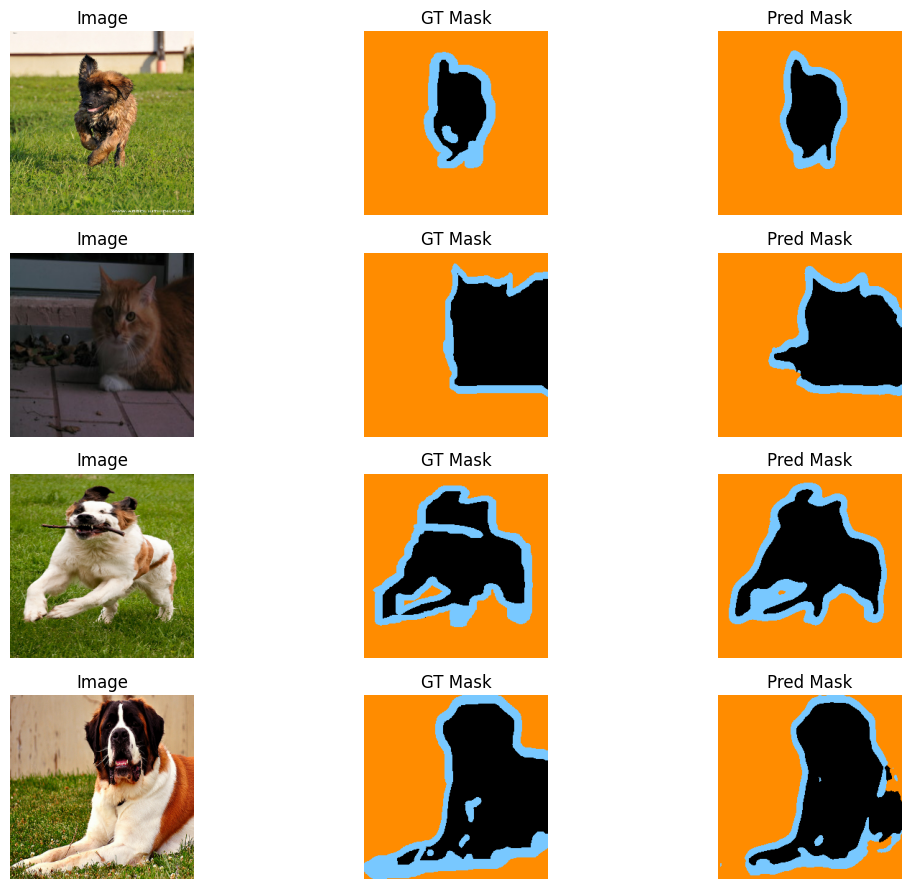

In [10]:
palette = np.array([
    [0, 0, 0],
    [255, 140, 0],
    [120, 200, 255]
], dtype=np.uint8)

def colorize(mask):
    return palette[mask.astype(np.int32)]

images, masks = next(iter(test_ds))
pred = model.predict(images, verbose=0)
pred_mask = tf.argmax(pred, axis=-1).numpy()

n = min(4, images.shape[0])
plt.figure(figsize=(12, 9))
for i in range(n):
    img = (images[i].numpy() * 255).astype(np.uint8)
    gt  = colorize(masks[i].numpy())
    pr  = colorize(pred_mask[i])

    plt.subplot(n, 3, i*3 + 1); plt.imshow(img); plt.axis("off"); plt.title("Image")
    plt.subplot(n, 3, i*3 + 2); plt.imshow(gt);  plt.axis("off"); plt.title("GT Mask")
    plt.subplot(n, 3, i*3 + 3); plt.imshow(pr);  plt.axis("off"); plt.title("Pred Mask")
plt.tight_layout()
plt.show()